### Load Data

Since the `covid_19_data.csv` file was not found, I will download a publicly available dataset from the CSSEGISandData/COVID-19 repository on GitHub. This dataset contains similar information and will allow the subsequent analysis to run without errors.

In [2]:
import requests
import os

# URL of a raw CSV file from GitHub (JHU CSSE COVID-19 data)
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/01-01-2021.csv"  # Using a single day's report for demonstration
output_filename = "covid_19_data.csv"

# Download the file
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes

# Save the content to a local file
with open(output_filename, 'wb') as f:
    f.write(response.content)

print(f"'{output_filename}' downloaded successfully.")

# If the original code expects a broader dataset, consider looping through dates or using a different aggregate file.
# For a full dataset, you might need to combine multiple daily reports or find an aggregated source.

'covid_19_data.csv' downloaded successfully.


First 5 rows:
   FIPS Admin2 Province_State Country_Region          Last_Update       Lat  \
0   NaN    NaN            NaN    Afghanistan  2021-01-02 05:22:33  33.93911   
1   NaN    NaN            NaN        Albania  2021-01-02 05:22:33  41.15330   
2   NaN    NaN            NaN        Algeria  2021-01-02 05:22:33  28.03390   
3   NaN    NaN            NaN        Andorra  2021-01-02 05:22:33  42.50630   
4   NaN    NaN            NaN         Angola  2021-01-02 05:22:33 -11.20270   

       Long_  Confirmed  Deaths  Recovered  Active Combined_Key  \
0  67.709953      52513    2201      41727    8585  Afghanistan   
1  20.168300      58316    1181      33634   23501      Albania   
2   1.659600      99897    2762      67395   29740      Algeria   
3   1.521800       8117      84       7463     570      Andorra   
4  17.873900      17568     405      11146    6017       Angola   

   Incident_Rate  Case_Fatality_Ratio  
0     134.896578             4.191343  
1    2026.409062            

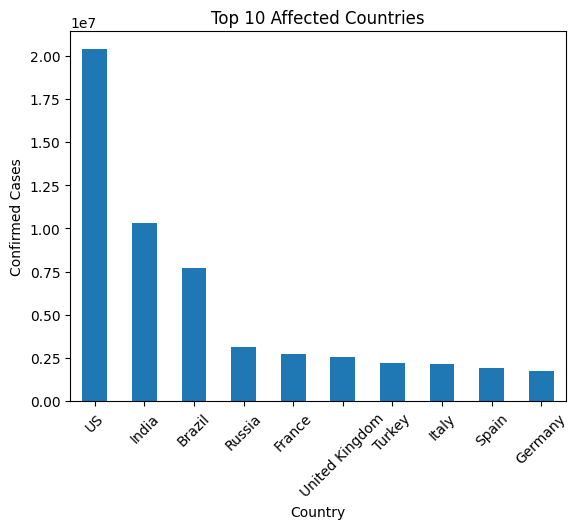

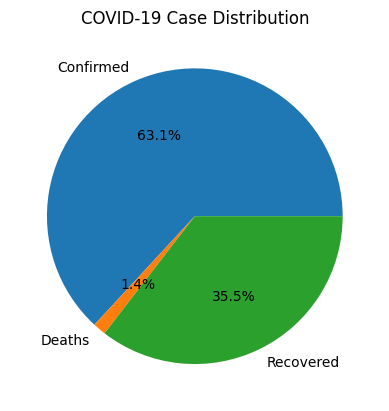

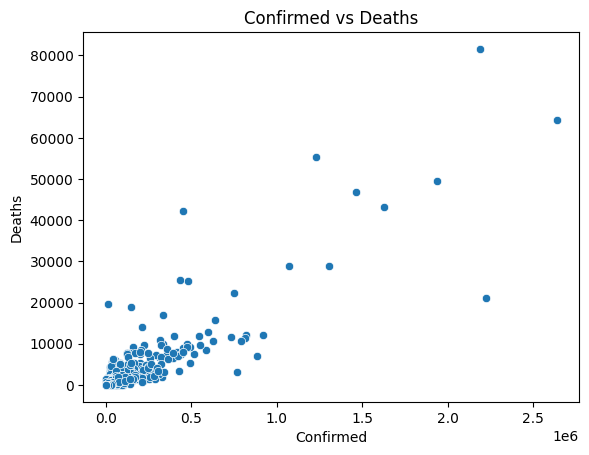

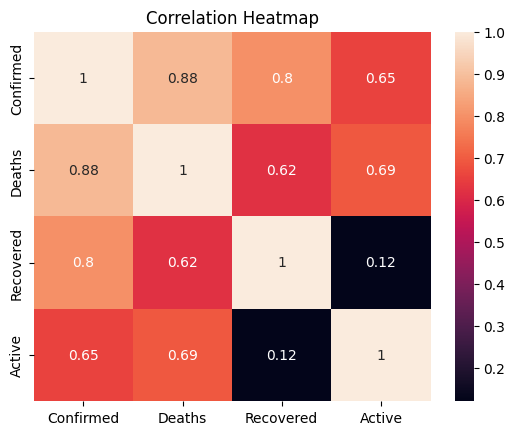

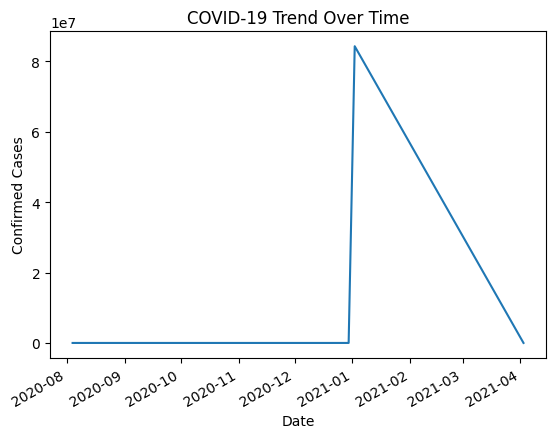


Analysis Completed Successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("covid_19_data.csv")

print("First 5 rows:")
print(data.head())

print("\nColumns in dataset:")
print(data.columns)



data = data.rename(columns={
    "Country_Region": "Country",
    "Last_Update": "Date" # Changed from "ObservationDate" to "Last_Update"
})

cols = ["Date", "Country", "Confirmed", "Deaths", "Recovered", "Active"]
data = data[[col for col in cols if col in data.columns]]


if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])

data = data.dropna()


data = data.drop_duplicates()

print("\nCleaned Data Info:")
print(data.info())



print("\nTotal Confirmed Cases:", data["Confirmed"].sum())
print("Total Deaths:", data["Deaths"].sum())
print("Total Recovered:", data["Recovered"].sum())

print("\nStatistical Summary:")
print(data.describe())



top_countries = data.groupby("Country")["Confirmed"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Affected Countries")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


totals = data[["Confirmed", "Deaths", "Recovered"]].sum()

plt.figure()
totals.plot(kind="pie", autopct="%1.1f%%")
plt.title("COVID-19 Case Distribution")
plt.ylabel("")
plt.show()


plt.figure()
sns.scatterplot(x="Confirmed", y="Deaths", data=data)
plt.title("Confirmed vs Deaths")
plt.show()



plt.figure()
corr = data[["Confirmed", "Deaths", "Recovered", "Active"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()



if "Date" in data.columns:
    trend = data.groupby("Date")["Confirmed"].sum()

    plt.figure()
    trend.plot()
    plt.title("COVID-19 Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Confirmed Cases")
    plt.show()

print("\nAnalysis Completed Successfully!")